In [31]:
import sys
!{sys.executable} -m pip install seaborn

In [32]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [33]:
conn = sqlite3.connect('/Users/sayali/Developer/Data/ML_Project/data/inventory.db')
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [34]:
purchase_agg_df = pd.read_sql_query("""
SELECT p.PONumber, count(distinct Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
FROM Purchases p
GROUP BY p.PONumber
""", conn)

In [35]:
purchase_agg_df.shape

(5543, 5)

In [36]:
pd.read_sql_query("""
SELECT  vi.PONumber, vi.Quantity as invoice_quantity, vi.Dollars as invoice_dollars, vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay
FROM vendor_invoice vi;        
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [37]:
df=pd.read_sql_query("""
WITH purchase_agg AS (
SELECT p.PONumber, count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
FROM Purchases p
GROUP BY p.PONumber
)
SELECT  vi.PONumber, vi.Quantity as invoice_quantity, vi.Dollars as invoice_dollars, vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands, pa.total_item_quantity, pa.total_item_dollars, pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa ON vi.PONumber = pa.PONumber;
""", conn)

In [38]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [39]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [40]:
def create_invoice_risk_label(row):
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
    if row["avg_receiving_delay"] > 10:
        return 1
   
    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

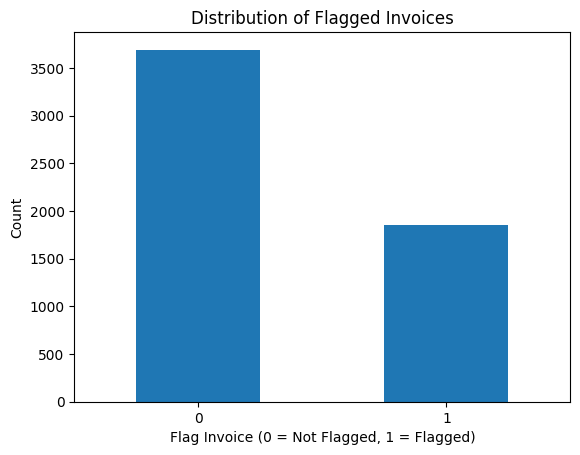

In [41]:
df['flag_invoice'].value_counts().plot(kind='bar')
plt.title('Distribution of Flagged Invoices')
plt.xlabel('Flag Invoice (0 = Not Flagged, 1 = Flagged)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [42]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


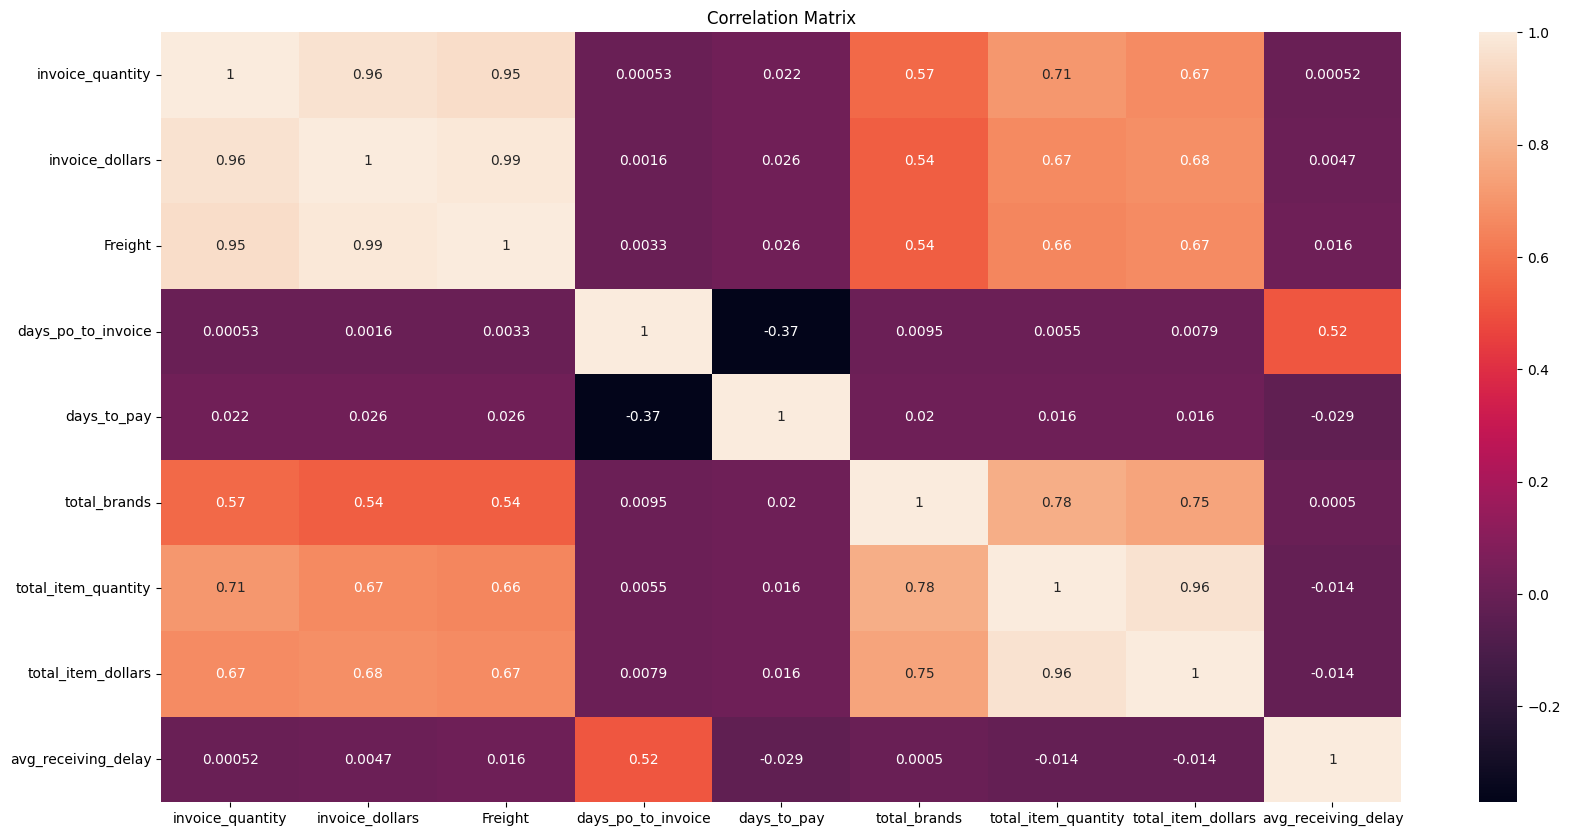

In [43]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

In [44]:
flagged = df[df['flag_invoice'] == 1]  
normal = df[df['flag_invoice'] == 0]


In [45]:
significant_features = []
non_significant_features = []
results = []

In [50]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [54]:
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    
    t_stat, p_value = ttest_ind(flagged[metric].dropna(), normal[metric].dropna(), equal_var=False)

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'Metric': metric,
            'Flagged Mean': flagged_mean.round(2),
            'Normal Mean': normal_mean.round(2),
            'P-Value': p_value.round(2)
        })
    else:

        non_significant_features.append(metric)
        print(metric)
        print(f"Flagged Mean: {flagged_mean:.2f}, Normal Mean: {normal_mean:.2f}, P-Value: {p_value:.4f}")

days_to_pay
Flagged Mean: 35.42, Normal Mean: 35.49, P-Value: 0.6924
total_brands
Flagged Mean: 42.29, Normal Mean: 40.82, P-Value: 0.5077


In [48]:
non_significant_features

['days_to_pay', 'total_brands']

In [49]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [52]:
results

[{'Metric': 'invoice_quantity',
  'Flagged Mean': 6728.28,
  'Normal Mean': 5723.55,
  'Mean Difference': 1004.7338305486637,
  'T-Statistic': 2.303691912622145,
  'P-Value': 0.02},
 {'Metric': 'invoice_dollars',
  'Flagged Mean': 65600.61,
  'Normal Mean': 54302.64,
  'Mean Difference': 11297.967459415544,
  'T-Statistic': 2.651798045413994,
  'P-Value': 0.01},
 {'Metric': 'Freight',
  'Flagged Mean': 334.02,
  'Normal Mean': 276.89,
  'Mean Difference': 57.13365949166064,
  'T-Statistic': 2.6463624783667083,
  'P-Value': 0.01},
 {'Metric': 'days_po_to_invoice',
  'Flagged Mean': 17.23,
  'Normal Mean': 16.02,
  'Mean Difference': 1.214287951639701,
  'T-Statistic': 13.753046752551812,
  'P-Value': 0.0},
 {'Metric': 'total_item_quantity',
  'Flagged Mean': 6728.28,
  'Normal Mean': 5723.55,
  'Mean Difference': 1004.728962610051,
  'T-Statistic': 2.3036806390418882,
  'P-Value': 0.02},
 {'Metric': 'total_item_dollars',
  'Flagged Mean': 65600.61,
  'Normal Mean': 54302.64,
  'Mean Dif

In [55]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice','total_item_dollars']]
y = df['flag_invoice']

In [57]:
X.describe()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03
mean,6058.880931,5.807338e+04,295.954301,41.312466,6058.880931,16.424499,5.807338e+04
std,14453.338164,1.402340e+05,713.585093,76.940674,14453.338164,3.127282,1.402340e+05
min,1.000000,4.140000e+00,0.020000,1.000000,1.000000,9.000000,4.140000e+00
25%,83.000000,9.678100e+02,5.020000,3.000000,83.000000,14.000000,9.678100e+02
50%,423.000000,4.765450e+03,24.730000,7.000000,423.000000,16.000000,4.765450e+03
75%,5100.500000,4.458718e+04,229.660000,46.000000,5100.500000,19.000000,4.458718e+04
max,141660.000000,1.660436e+06,8468.220000,807.000000,141660.000000,23.000000,1.660436e+06


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix

In [67]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [78]:
model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
model3 = DecisionTreeClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [80]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {model_name}:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

In [82]:
evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, X_test_scaled, y_test, "Random Forest")


Evaluation for Logistic Regression:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.56      0.06      0.11       384

    accuracy                           0.66      1109
   macro avg       0.61      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

Confusion Matrix:
[[707  18]
 [361  23]]


Evaluation for Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      0.68      0.79       384

    accuracy                           0.87      1109
   macro avg       0.89      0.83      0.85      1109
weighted avg       0.88      0.87      0.87      1109

Confusion Matrix:
[[707  18]
 [121 263]]




In [83]:
evaluate_model(model3, X_test_scaled, y_test, "Decision Tree")

Evaluation for Decision Tree:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       725
           1       0.74      0.71      0.72       384

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

Confusion Matrix:
[[627  98]
 [111 273]]




In [87]:
model2.feature_importances_

array([0.15208602, 0.15015318, 0.14429552, 0.0805667 , 0.17730454,
       0.07708204, 0.21851199])

In [88]:
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model2.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

feature_importances

,Feature,Importance
6,total_item_dollars,0.218512
4,total_item_quantity,0.177305
0,invoice_quantity,0.152086
1,invoice_dollars,0.150153
2,Freight,0.144296
3,total_brands,0.080567
5,days_po_to_invoice,0.077082


In [92]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = RandomForestClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
evaluate_model(model2, X_test_scaled, y_test, "Random Forest")

Evaluation for Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.94      0.68      0.79       384

    accuracy                           0.87      1109
   macro avg       0.89      0.83      0.85      1109
weighted avg       0.88      0.87      0.87      1109

Confusion Matrix:
[[707  18]
 [121 263]]




In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring=scorer, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search.best_estimator_, X_test_scaled, y_test, "Tuned Random Forest")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.3s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   3.9s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   4.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

In [95]:
evaluate_model(grid_search.best_estimator_, X_test_scaled, y_test, "Tuned Random Forest")

Evaluation for Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       725
           1       0.95      0.68      0.79       384

    accuracy                           0.87      1109
   macro avg       0.90      0.83      0.85      1109
weighted avg       0.88      0.87      0.87      1109

Confusion Matrix:
[[710  15]
 [124 260]]




In [96]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[710, 124],
       [ 15, 260]])

In [97]:
confusion_matrix(model2.predict(X_test_scaled), y_test)

array([[707, 121],
       [ 18, 263]])

In [98]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 100}